# 📊 Credit Risk — Exploratory Data Analysis

Full EDA of the Loan Default dataset before modelling.

In [5]:
!pip install pandas 
!pip install numpy 
!pip install matplotlib 
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('data/Loan_default.csv')
print(df.shape)
df.head()

(255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 1 · Basic Info & Missing Values

In [2]:
df.info()
print('\nMissing values per column:')
print(df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


## 2 · Target Distribution

C:\Users\Brunda\AppData\Local\Temp\ipykernel_3868\1897470034.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Default', data=df, palette=['#00c6ff','#ff4b4b'], ax=axes[1])
C:\Users\Brunda\AppData\Local\Temp\ipykernel_3868\1897470034.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Default','Default'])


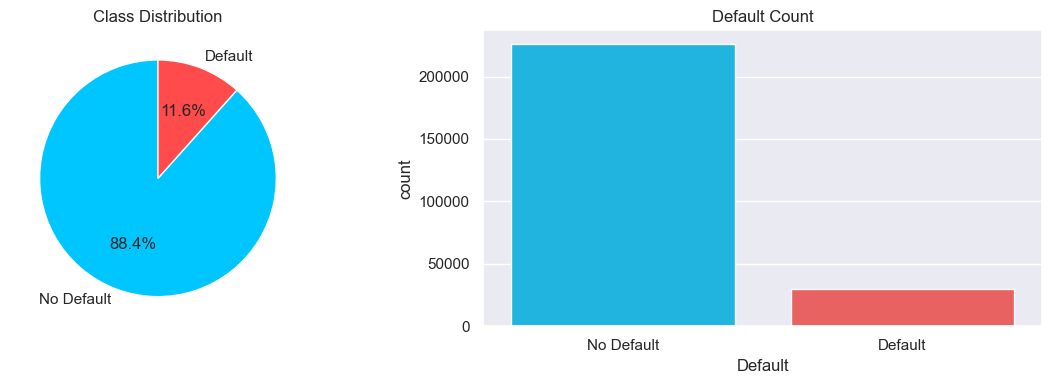

Imbalance ratio  →  7.61:1


In [3]:
counts = df['Default'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(counts, labels=['No Default','Default'],
            autopct='%1.1f%%', colors=['#00c6ff','#ff4b4b'], startangle=90)
axes[0].set_title('Class Distribution')

sns.countplot(x='Default', data=df, palette=['#00c6ff','#ff4b4b'], ax=axes[1])
axes[1].set_xticklabels(['No Default','Default'])
axes[1].set_title('Default Count')

plt.tight_layout()
plt.show()
print(f'Imbalance ratio  →  {counts[0]/counts[1]:.2f}:1')

## 3 · Numerical Feature Distributions by Default Status

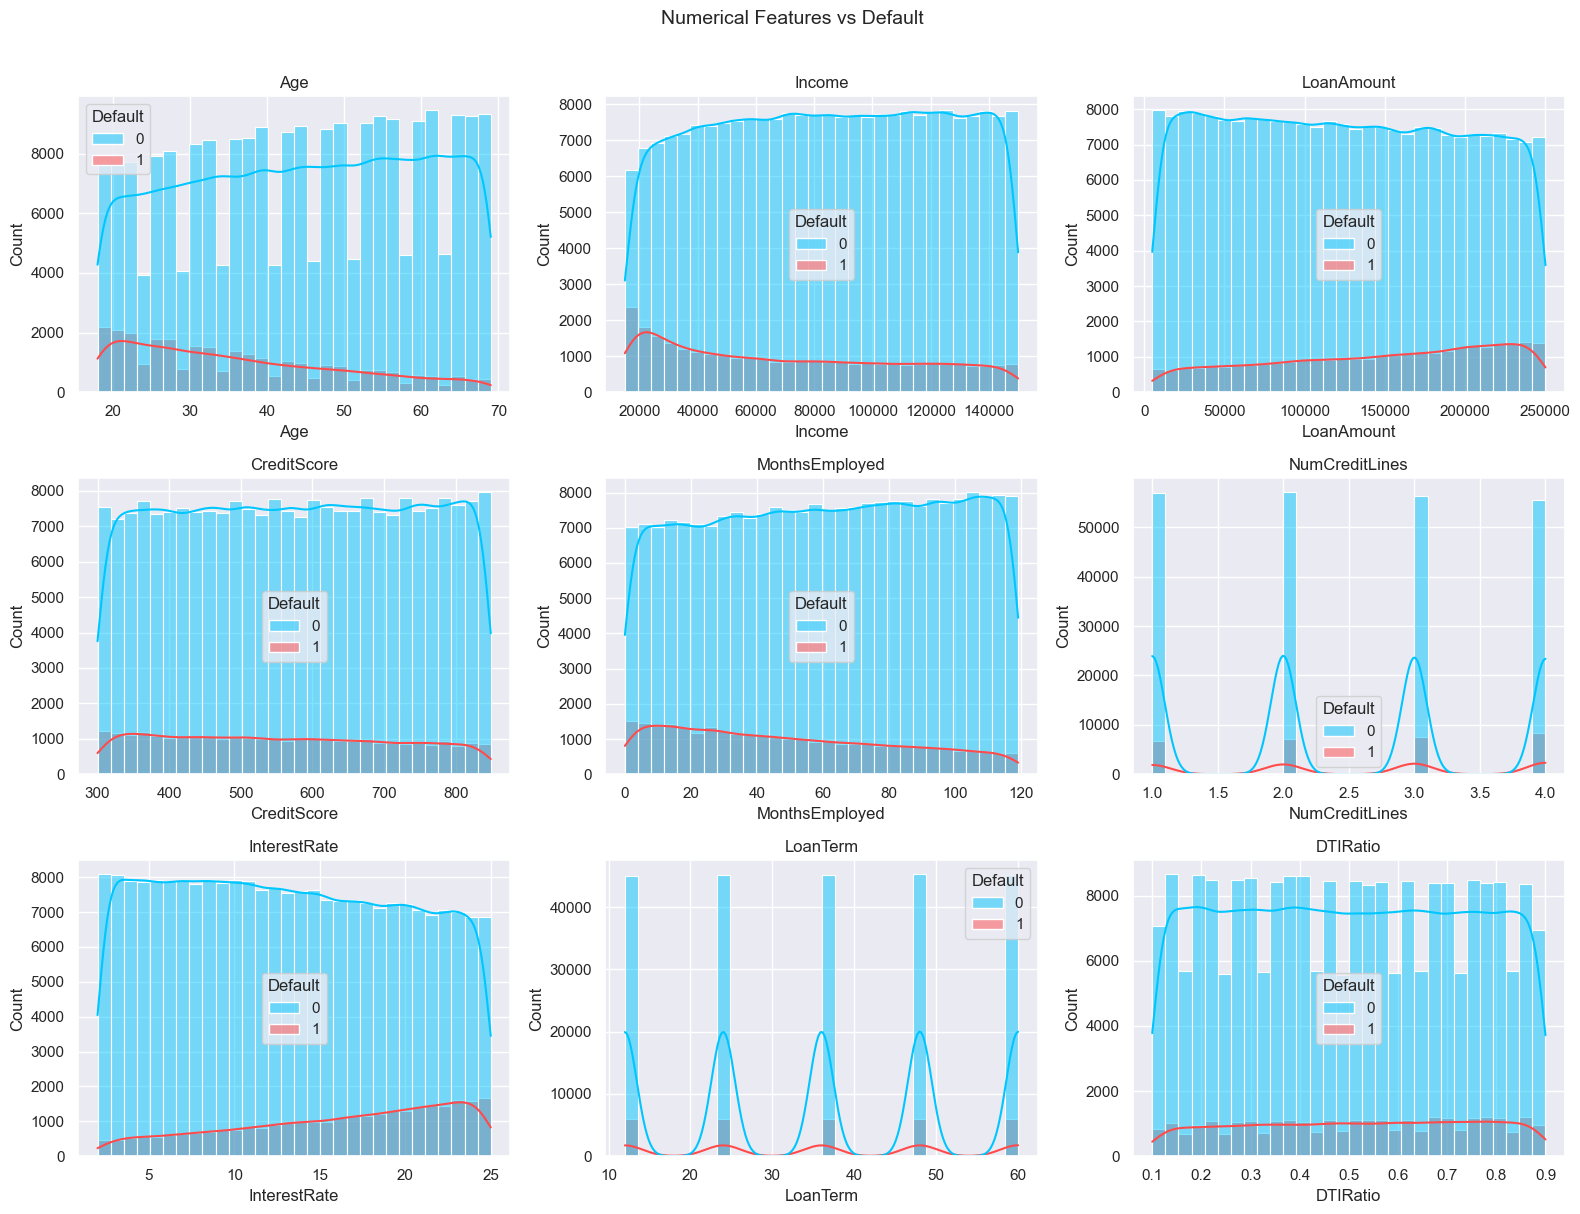

In [4]:
num_cols = df.select_dtypes(include=np.number).columns.drop('Default').tolist()
n_cols = 3
n_rows = -(-len(num_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Default',
                 palette={0:'#00c6ff', 1:'#ff4b4b'}, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs Default', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 · Categorical Features vs Default

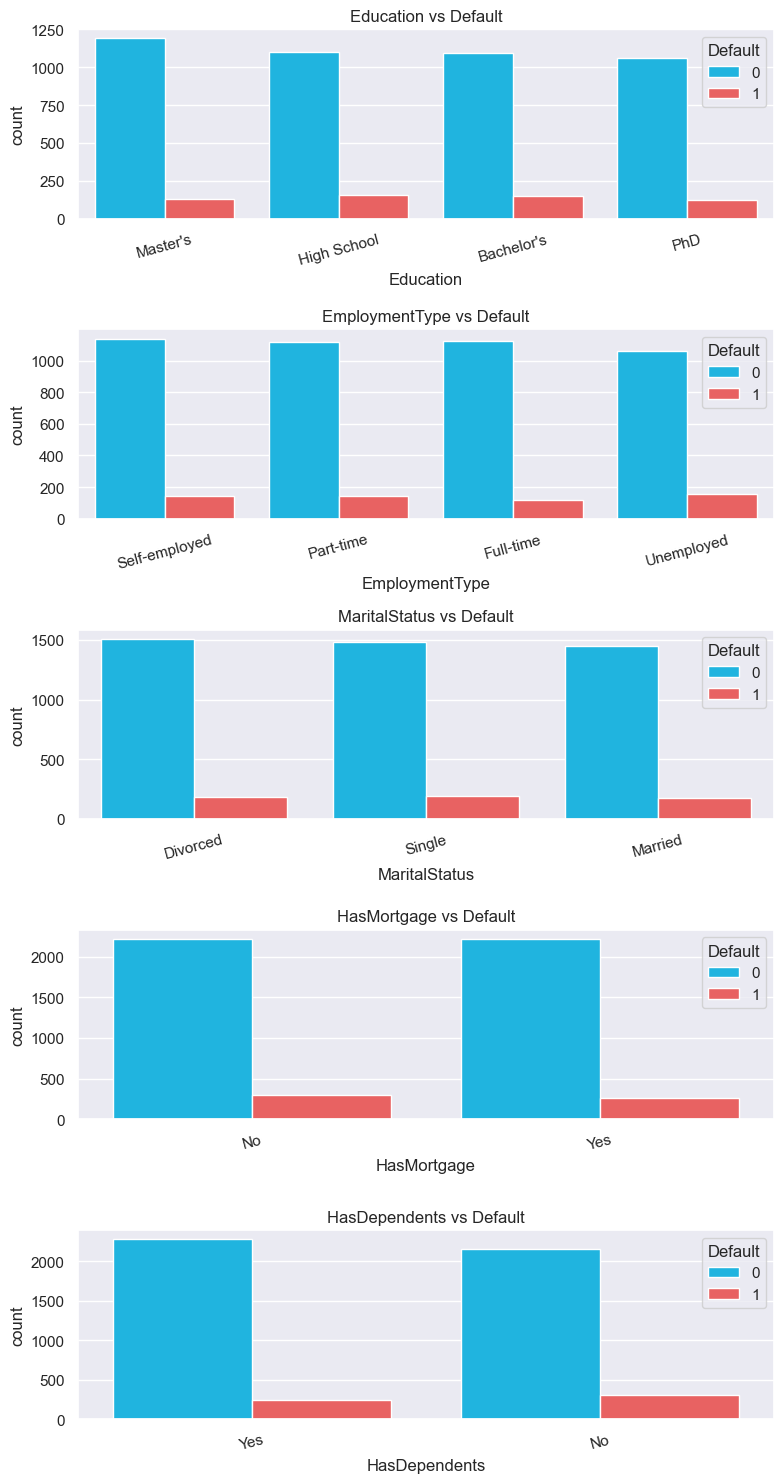

In [5]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

# remove high-cardinality columns
cat_cols = [col for col in cat_cols if df[col].nunique() < 10]

# limit number of plots
cat_cols = cat_cols[:5]

# sample data
df_sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(8, len(cat_cols)*3))

if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    order = df_sample[col].value_counts().index
    sns.countplot(
        data=df_sample,
        x=col,
        hue='Default',
        palette={0:'#00c6ff', 1:'#ff4b4b'},
        order=order,
        ax=ax
    )
    ax.set_title(f'{col} vs Default')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 5 · Default Rate by Category

In [6]:
for col in cat_cols:
    rates = df.groupby(col)['Default'].mean().sort_values(ascending=False)
    print(f'\n--- Default Rate by {col} ---')
    print((rates * 100).round(2).astype(str) + '%')


--- Default Rate by Education ---
Education
High School    12.88%
Bachelor's      12.1%
Master's       10.87%
PhD            10.59%
Name: Default, dtype: str

--- Default Rate by EmploymentType ---
EmploymentType
Unemployed       13.55%
Part-time        11.97%
Self-employed    11.46%
Full-time         9.46%
Name: Default, dtype: str

--- Default Rate by MaritalStatus ---
MaritalStatus
Divorced    12.53%
Single      11.91%
Married      10.4%
Name: Default, dtype: str

--- Default Rate by HasMortgage ---
HasMortgage
No     12.35%
Yes    10.88%
Name: Default, dtype: str

--- Default Rate by HasDependents ---
HasDependents
No     12.72%
Yes     10.5%
Name: Default, dtype: str


## 6 · Correlation Heatmap

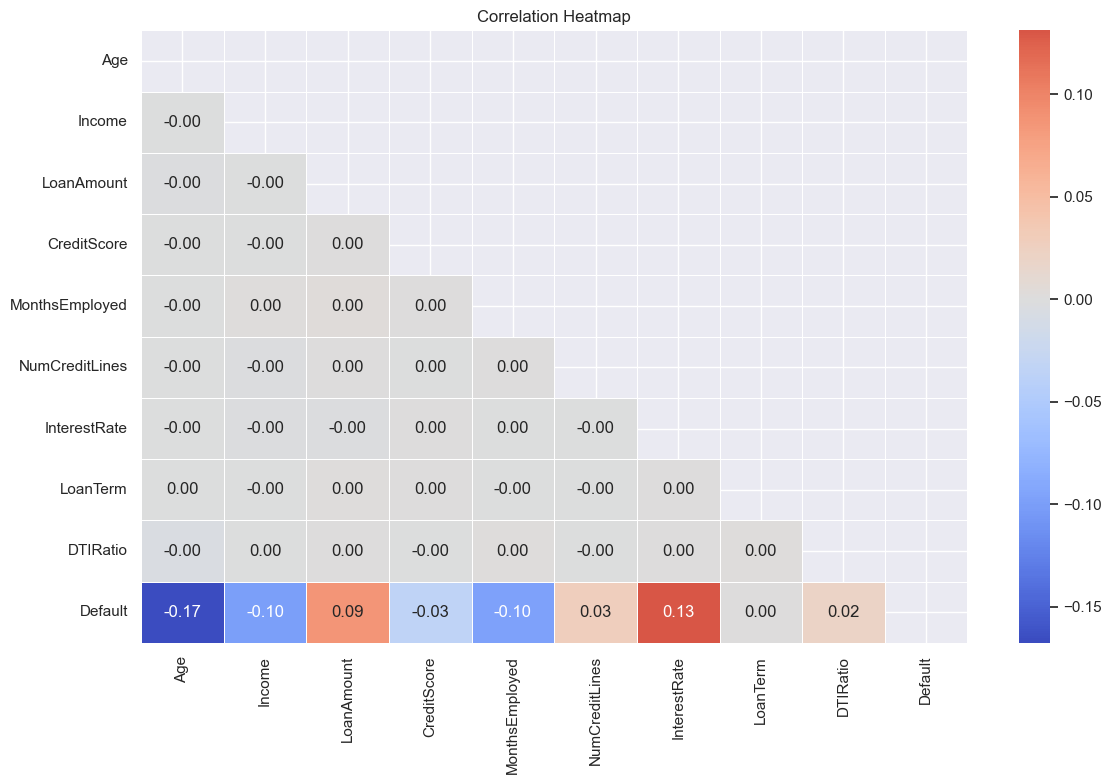

In [7]:
corr = df[num_cols + ['Default']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7 · Boxplots — Key Features vs Default

C:\Users\Brunda\AppData\Local\Temp\ipykernel_3868\3161666928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Default', y=col,
C:\Users\Brunda\AppData\Local\Temp\ipykernel_3868\3161666928.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Default','Default'])
C:\Users\Brunda\AppData\Local\Temp\ipykernel_3868\3161666928.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Default', y=col,
C:\Users\Brunda\AppData\Local\Temp\ipykernel_3868\3161666928.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or

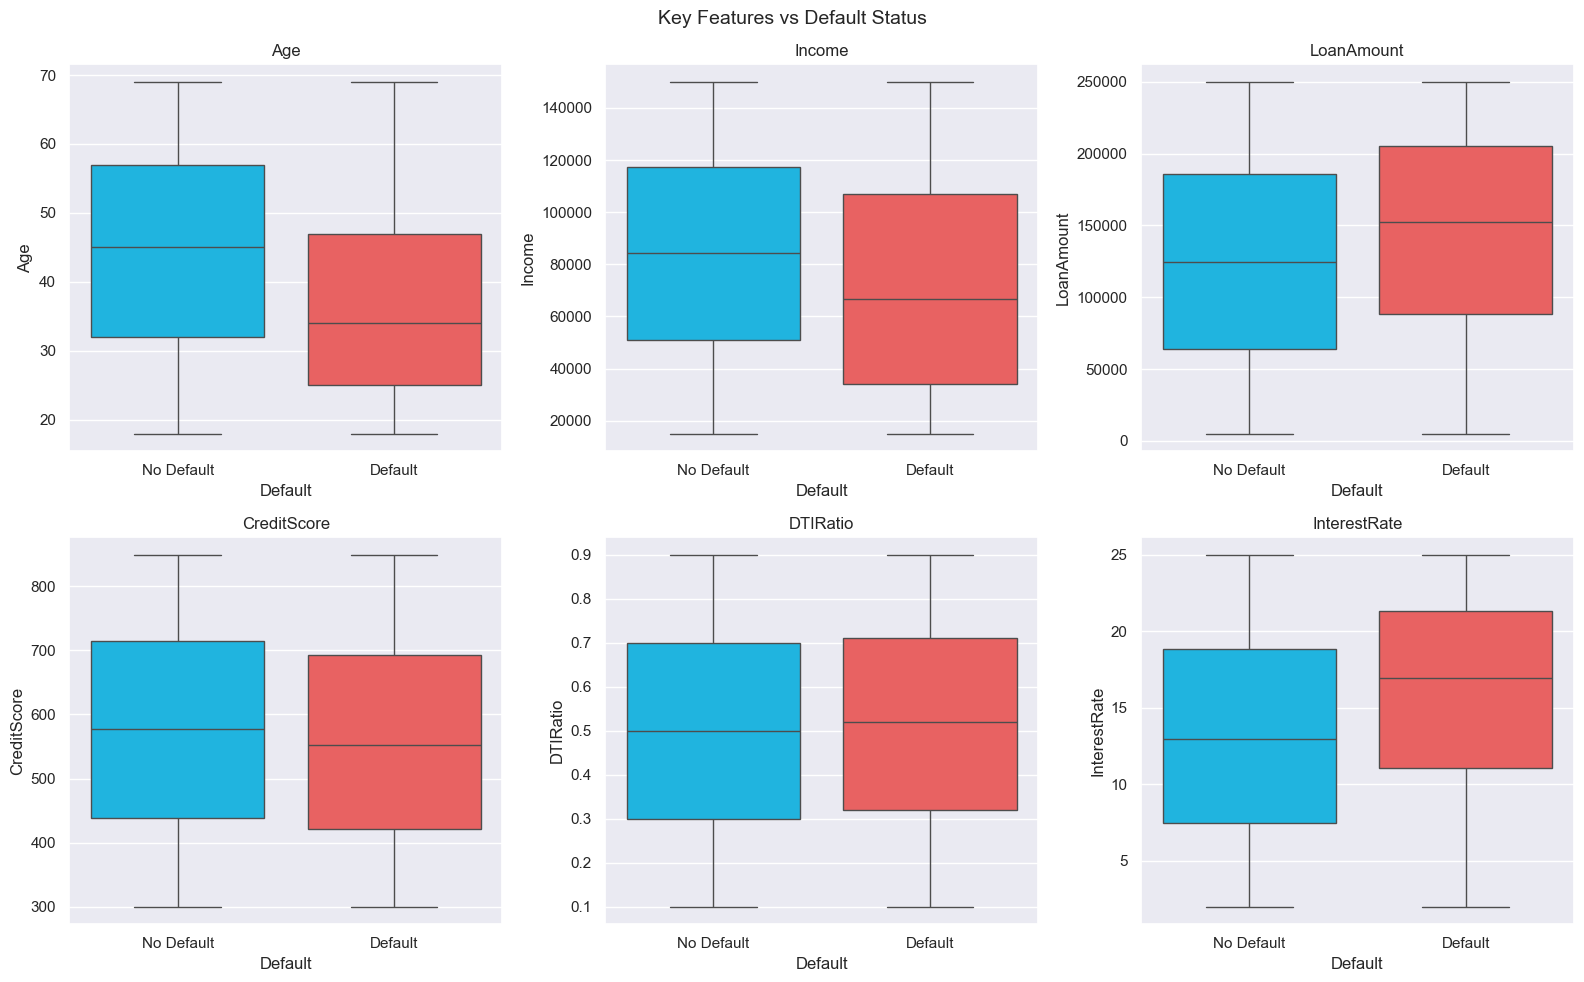

In [9]:
key_features = [f for f in ['Age','Income','LoanAmount','CreditScore','DTIRatio','InterestRate'] if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), key_features):
    sns.boxplot(data=df, x='Default', y=col,
                palette={'0':'#00c6ff', '1':'#ff4b4b'}, ax=ax)
    ax.set_xticklabels(['No Default','Default'])
    ax.set_title(col)

plt.suptitle('Key Features vs Default Status', fontsize=14)
plt.tight_layout()
plt.show()

## 8 · Pairplot — Top 5 Features Most Correlated with Default

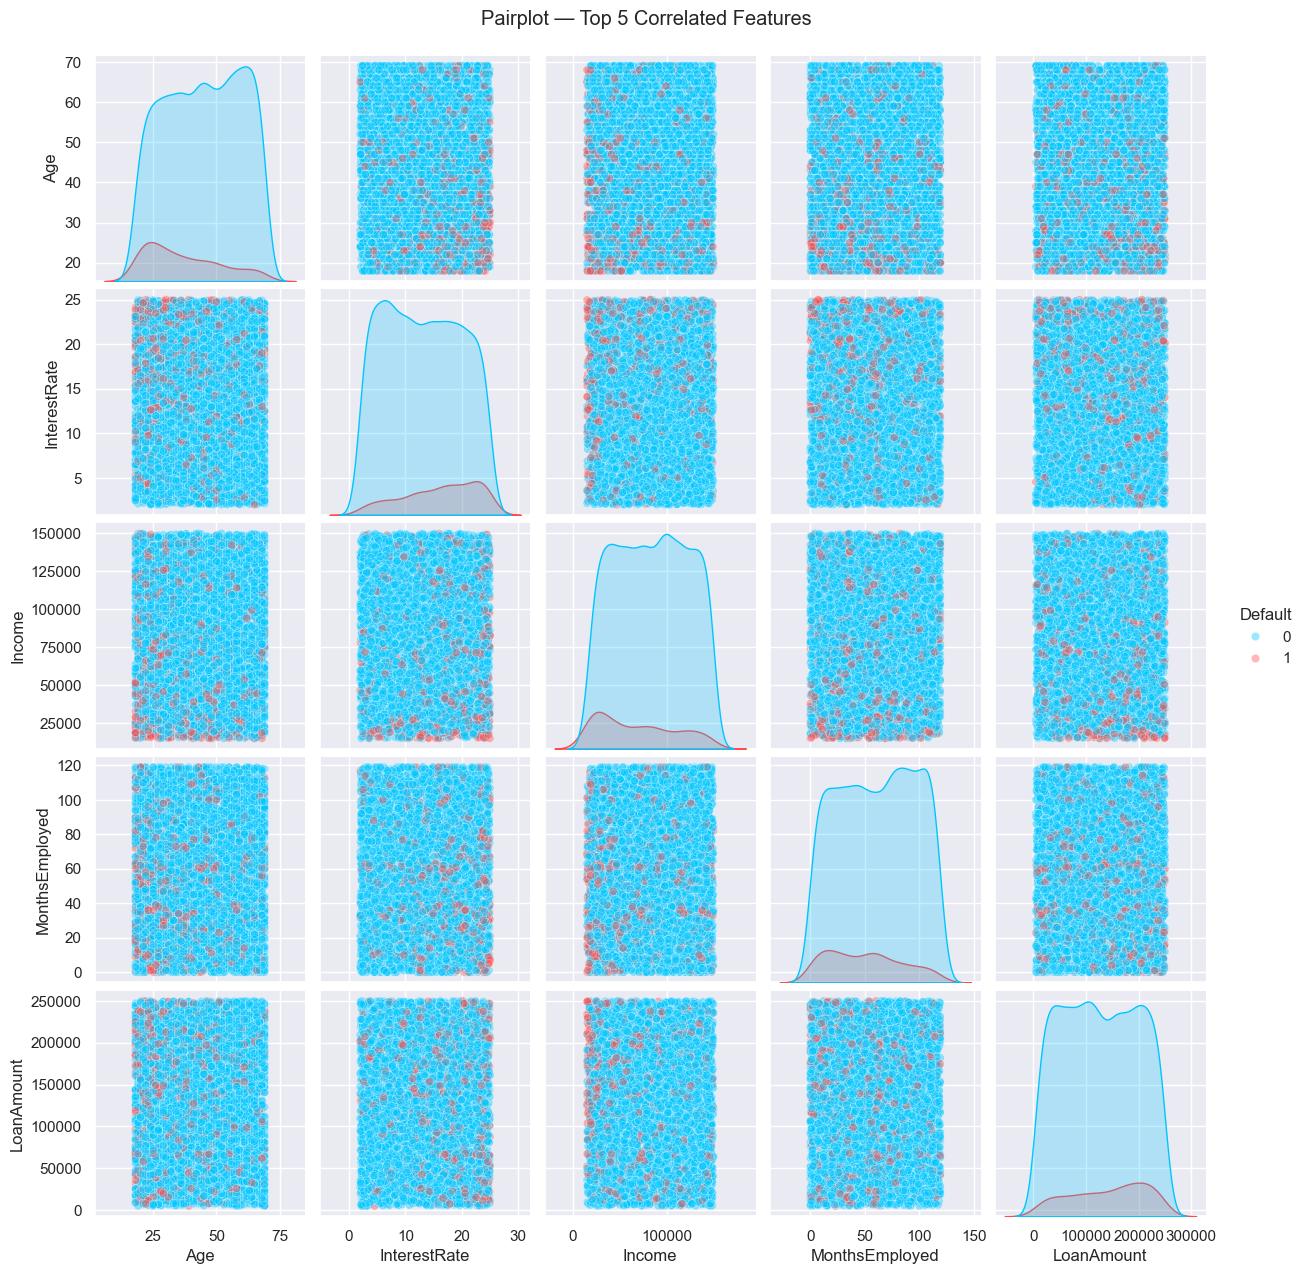

In [14]:
top5 = corr['Default'].abs().drop('Default').nlargest(5).index.tolist()

sns.pairplot(df_sample[top5 + ['Default']], hue='Default',
             palette={0:'#00c6ff', 1:'#ff4b4b'},
             diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot — Top 5 Correlated Features', y=1.02)
plt.show()

## 9 · Summary & Key Insights

In [15]:
print('=== KEY INSIGHTS ===')
print(f'Rows / Columns : {df.shape}')
print(f'Default rate   : {df["Default"].mean():.2%}')
print(f'Missing values : {df.isnull().sum().sum()}')
print(f'\nTop 5 features correlated with Default:')
print(corr['Default'].abs().drop('Default').nlargest(5).round(3))

=== KEY INSIGHTS ===
Rows / Columns : (255347, 18)
Default rate   : 11.61%
Missing values : 0

Top 5 features correlated with Default:
Age               0.168
InterestRate      0.131
Income            0.099
MonthsEmployed    0.097
LoanAmount        0.087
Name: Default, dtype: float64
